# Challenge Alura Store
### Objetivo é ajudar o Sr. João a decidir qual das suas 4 lojas vender para investir em um novo negócio

### Métricas:
#### - Faturamento total de cada loja
#### - Categorias mais populares
#### - Média de avaliações dos clientes
#### - Produtos mais e menos vendidos
#### - Custo médio do frete


In [153]:
# Importando a biblioteca Pandas

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [128]:
# Importando as bases de dados

url_1 = 'https://raw.githubusercontent.com/vanrpontes/challenge1-alura-store/refs/heads/main/dados/loja_1.csv'
url_2 = 'https://raw.githubusercontent.com/vanrpontes/challenge1-alura-store/refs/heads/main/dados/loja_2.csv'
url_3 = 'https://raw.githubusercontent.com/vanrpontes/challenge1-alura-store/refs/heads/main/dados/loja_3.csv'
url_4 = 'https://raw.githubusercontent.com/vanrpontes/challenge1-alura-store/refs/heads/main/dados/loja_4.csv'

In [129]:
# Carregando os dados de cada loja em DataFrames individuais

dados_1 = pd.read_csv(url_1)
dados_2 = pd.read_csv(url_2)
dados_3 = pd.read_csv(url_3)
dados_4 = pd.read_csv(url_4)



In [130]:
# Criando a coluna 'Loja' para identificar a origem de cada registro

dados_1['Loja'] = 'Loja 1'
dados_2['Loja'] = 'Loja 2'
dados_3['Loja'] = 'Loja 3'
dados_4['Loja'] = 'Loja 4'

In [131]:
# Unificando os dados das quatro lojas em um único DataFrame para análise comparativa

dados = pd.concat ([dados_1, dados_2, dados_3, dados_4], ignore_index=True)

dados

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9430,Mesa de jantar,moveis,303.60,16.852799,12/02/2020,Camila Ribeiro,RJ,5,cartao_credito,1,-22.25,-42.66,Loja 4
9431,Cadeira de escritório,moveis,456.02,24.812798,17/05/2022,Felipe Santos,PE,5,cartao_credito,3,-8.38,-37.86,Loja 4
9432,Copo térmico,esporte e lazer,48.99,3.139675,03/05/2022,Camila Ribeiro,SP,5,cartao_credito,1,-22.19,-48.79,Loja 4
9433,Jogo de panelas,utilidades domesticas,202.45,11.062979,15/06/2020,Bianca Santos,PR,5,cartao_credito,1,-24.89,-51.55,Loja 4


In [132]:
# Conferindo os registros por Loja

dados['Loja'].value_counts()

,count
Loja,
Loja 1,2359
Loja 2,2359
Loja 3,2359
Loja 4,2358


In [133]:
# Verificando a estrutura e os tipos de dados do DataFrame consolidado

dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9435 entries, 0 to 9434
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Produto                 9435 non-null   object 
 1   Categoria do Produto    9435 non-null   object 
 2   Preço                   9435 non-null   float64
 3   Frete                   9435 non-null   float64
 4   Data da Compra          9435 non-null   object 
 5   Vendedor                9435 non-null   object 
 6   Local da compra         9435 non-null   object 
 7   Avaliação da compra     9435 non-null   int64  
 8   Tipo de pagamento       9435 non-null   object 
 9   Quantidade de parcelas  9435 non-null   int64  
 10  lat                     9435 non-null   float64
 11  lon                     9435 non-null   float64
 12  Loja                    9435 non-null   object 
dtypes: float64(4), int64(2), object(7)
memory usage: 958.4+ KB


In [135]:
# Verificando os 5 primeiros registros

dados.head()

,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon,Loja
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79,Loja 1
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66,Loja 1
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86,Loja 1
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50,Loja 1
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38,Loja 1


#1. Análise do faturamento

In [139]:
# Cálculo e Print do Faturamento Total por Loja (Ordenado e Formatado em R$ BR)

faturamento = dados.groupby('Loja')['Preço'].sum().sort_values(ascending=False)

for loja, valor in faturamento.items():
    print(f'{loja}: R$ {valor:,.2f}')


Loja 1: R$ 1,534,509.12
Loja 2: R$ 1,488,459.06
Loja 3: R$ 1,464,025.03
Loja 4: R$ 1,384,497.58


In [140]:
faturamento = dados.groupby('Loja')[['Preço']].sum().sort_values('Preço', ascending=False)

# Calcular o Faturamento Total Geral (numérico)
faturamento_total = faturamento['Preço'].sum()

# Criar uma cópia p/ formatação
faturamento_exibicao = faturamento.copy()

# Criar a coluna 'Percentual' (valor float) na cópia
faturamento_exibicao['Percentual'] = (faturamento_exibicao['Preço'] / faturamento_total) * 100

# 4. Formatar as colunas para exibição (Moeda e Percentual)
faturamento_exibicao['Faturamento Formatado'] = faturamento_exibicao['Preço'].map('R$ {:,.2f}'.format)
faturamento_exibicao['Participação'] = faturamento_exibicao['Percentual'].map('{:.2f}%'.format)

# 5. EXCLUIR as colunas float **APENAS DA CÓPIA DE EXIBIÇÃO**
faturamento_final_exibicao = faturamento_exibicao.drop(columns=['Preço', 'Percentual'])

# 6. Adicionar a linha de Total Geral (usando o faturamento_total float)
total_row = pd.DataFrame({
    'Faturamento Formatado': ['R$ {:,.2f}'.format(faturamento_total)],
    'Participação': ['100.00%']
}, index=['TOTAL'])

faturamento_final = pd.concat([faturamento_final_exibicao, total_row])

# Renomeando a coluna final para Faturamento
faturamento_final = faturamento_final.rename(columns={'Faturamento Formatado': 'Faturamento'})

print(faturamento_final)

            Faturamento Participação
Loja 1  R$ 1,534,509.12       26.13%
Loja 2  R$ 1,488,459.06       25.35%
Loja 3  R$ 1,464,025.03       24.93%
Loja 4  R$ 1,384,497.58       23.58%
TOTAL   R$ 5,871,490.79      100.00%


# 2. Vendas por Categoria

In [144]:
# CALCULA E ORDENA: Faturamento Total por Categoria do Produto

vendas_categoria = dados.groupby('Categoria do Produto')['Preço'].sum().sort_values(ascending=False)
print(vendas_categoria)

Categoria do Produto
eletronicos              2214099.72
eletrodomesticos         1766337.03
moveis                   1010214.00
instrumentos musicais     465029.67
esporte e lazer           190635.39
brinquedos                 98140.86
utilidades domesticas      76773.38
livros                     50260.74
Name: Preço, dtype: float64


In [145]:
# DataFrame inicial de Vendas por Categoria:
vendas_categoria = dados.groupby('Categoria do Produto')[['Preço']].sum().sort_values('Preço', ascending=False)

# 1. Calcular o Faturamento Total Geral (para categorias, é o mesmo total geral)
total_vendas_categoria = vendas_categoria['Preço'].sum()

# 2. Criar a coluna 'Percentual' (valor float)
vendas_categoria['Percentual'] = (vendas_categoria['Preço'] / total_vendas_categoria) * 100

# 3. Formatar as colunas para exibição (Moeda e Percentual - Padrão Americano)
vendas_categoria['Faturamento'] = vendas_categoria['Preço'].map('R$ {:,.2f}'.format)
vendas_categoria['Participação'] = vendas_categoria['Percentual'].map('{:.2f}%'.format)

# 4. Excluir as colunas float originais
vendas_categoria = vendas_categoria.drop(columns=['Preço', 'Percentual'])

# 5. Adicionar a linha de Total Geral
total_row_cat = pd.DataFrame({
    'Faturamento': ['R$ {:,.2f}'.format(total_vendas_categoria)],
    'Participação': ['100.00%']
}, index=['TOTAL'])

# 6. Concatenar o resultado final
vendas_categoria_final = pd.concat([vendas_categoria, total_row_cat])

print("\n### Vendas por Categoria (Faturamento e Participação):")
print(vendas_categoria_final)


### Vendas por Categoria (Faturamento e Participação):
                           Faturamento Participação
eletronicos            R$ 2,214,099.72       37.71%
eletrodomesticos       R$ 1,766,337.03       30.08%
moveis                 R$ 1,010,214.00       17.21%
instrumentos musicais    R$ 465,029.67        7.92%
esporte e lazer          R$ 190,635.39        3.25%
brinquedos                R$ 98,140.86        1.67%
utilidades domesticas     R$ 76,773.38        1.31%
livros                    R$ 50,260.74        0.86%
TOTAL                  R$ 5,871,490.79      100.00%


# 3. Média de Avaliação das Lojas

In [146]:
avaliacao = dados.groupby('Loja')[['Avaliação da compra']].mean().sort_values('Avaliação da compra', ascending=False).round(1)

avaliacao

,Avaliação da compra
Loja,
Loja 3,4.0
Loja 2,4.0
Loja 4,4.0
Loja 1,4.0


# 4. Produtos Mais e Menos Vendidos

In [147]:
# Contagem de vendas
contagem_vendas = dados['Produto'].value_counts()

# Top 10
top_10 = contagem_vendas.head(10)
print("TOP 10 Produtos Mais Vendidos:")
print(top_10)

# Bottom 10
bottom_10 = contagem_vendas.tail(10)
print("\nBOTTOM 10 Produtos Menos Vendidos:")
print(bottom_10)

# Se quiser ver o faturamento junto (ainda simples):
faturamento_produto = dados.groupby('Produto')['Preço'].sum()

print("\nTOP 10 com Faturamento:")
for produto in top_10.index:
    print(f'{produto}: {top_10[produto]} vendas - R$ {faturamento_produto[produto]:,.2f}')

TOP 10 Produtos Mais Vendidos:
Produto
Cômoda                      210
Carrinho controle remoto    206
Micro-ondas                 206
Bateria                     203
Cama king                   201
Secadora de roupas          200
Modelagem preditiva         200
Jogo de panelas             200
Cama box                    199
Blocos de montar            199
Name: count, dtype: int64

BOTTOM 10 Produtos Menos Vendidos:
Produto
Panela de pressão              172
Smartwatch                     172
Jogo de copos                  169
Poltrona                       168
Assistente virtual             167
Ciência de dados com python    166
Guitarra                       165
Mochila                        163
Headset                        158
Celular ABXY                   157
Name: count, dtype: int64

TOP 10 com Faturamento:
Cômoda: 210 vendas - R$ 77,892.33
Carrinho controle remoto: 206 vendas - R$ 19,690.62
Micro-ondas: 206 vendas - R$ 154,267.24
Bateria: 203 vendas - R$ 197,074.45
Cama kin

In [148]:
# 1. Contagem de Vendas para todos os 51 produtos (Série ordenada por Contagem)
contagem_vendas = dados['Produto'].value_counts()

# 2. Convertendo a Serie em DataFrame e renomeiando a coluna
todos_produtos = contagem_vendas.to_frame()
todos_produtos.columns = ['Contagem']

# 3. Adiciona o Faturamento (Calculado na Célula 2)
# faturamento_por_produto deve ser executado antes, na Célula 2 ou antes.
# Assumindo que faturamento_por_produto já existe:
todos_produtos = todos_produtos.join(faturamento_por_produto)
todos_produtos = todos_produtos.rename(columns={'Preço': 'Faturamento'})

# 4. Formatação para Moeda (padrão americano, ainda não consegui formatar no pt-br)
todos_produtos['Faturamento Formatado'] = todos_produtos['Faturamento'].map('R$ {:,.2f}'.format)

print("\n### Análise de Todos os Produtos: Contagem vs. Faturamento")
print(todos_produtos[['Contagem', 'Faturamento Formatado']])


### Análise de Todos os Produtos: Contagem vs. Faturamento
                             Contagem Faturamento Formatado
Produto                                                    
Cômoda                            210          R$ 77,892.33
Carrinho controle remoto          206          R$ 19,690.62
Micro-ondas                       206         R$ 154,267.24
Bateria                           203         R$ 197,074.45
Cama king                         201         R$ 181,040.36
Secadora de roupas                200         R$ 280,317.31
Modelagem preditiva               200          R$ 16,820.71
Jogo de panelas                   200          R$ 40,675.34
Cama box                          199         R$ 138,797.42
Blocos de montar                  199           R$ 9,069.86
Celular Plus X42                  198         R$ 534,735.14
Guarda roupas                     197         R$ 128,328.09
Pandeiro                          197          R$ 16,884.72
Bola de basquete                  197   

In [150]:
# Faturamento total gerado por cada produto
faturamento_por_produto = dados.groupby('Produto')['Preço'].sum()

top_10_produtos = contagem_vendas.head(10).to_frame()

top_10_produtos.columns = ['Contagem']

top_10_produtos = top_10_produtos.join(faturamento_por_produto)

top_10_produtos = top_10_produtos.rename(columns={'Preço': 'Faturamento'})

# 5. Formatação do Faturamento para moeda
top_10_produtos['Faturamento Formatado'] = top_10_produtos['Faturamento'].map('R$ {:,.2f}'.format)

print("\n### TOP 10 Produtos: Contagem de Vendas vs. Faturamento")
print(top_10_produtos[['Contagem', 'Faturamento Formatado']])


### TOP 10 Produtos: Contagem de Vendas vs. Faturamento
                          Contagem Faturamento Formatado
Produto                                                 
Cômoda                         210          R$ 77,892.33
Carrinho controle remoto       206          R$ 19,690.62
Micro-ondas                    206         R$ 154,267.24
Bateria                        203         R$ 197,074.45
Cama king                      201         R$ 181,040.36
Secadora de roupas             200         R$ 280,317.31
Modelagem preditiva            200          R$ 16,820.71
Jogo de panelas                200          R$ 40,675.34
Cama box                       199         R$ 138,797.42
Blocos de montar               199           R$ 9,069.86


In [151]:
bottom_10_produtos = contagem_vendas.tail(10).to_frame()

# Renomeia a coluna 'count' para 'Contagem'
bottom_10_produtos.columns = ['Contagem']

# Adiciona o Faturamento
bottom_10_produtos = bottom_10_produtos.join(faturamento_por_produto)

# Renomeia a coluna de preço para 'Faturamento'
bottom_10_produtos = bottom_10_produtos.rename(columns={'Preço': 'Faturamento'})

# Formatação do Faturamento para Moeda
bottom_10_produtos['Faturamento Formatado'] = bottom_10_produtos['Faturamento'].map('R$ {:,.2f}'.format)

print("\n### BOTTOM 10 Produtos: Contagem de Vendas vs. Faturamento")
print(bottom_10_produtos[['Contagem', 'Faturamento Formatado']])


### BOTTOM 10 Produtos: Contagem de Vendas vs. Faturamento
                             Contagem Faturamento Formatado
Produto                                                    
Panela de pressão                 172          R$ 17,238.91
Smartwatch                        172          R$ 39,905.90
Jogo de copos                     169           R$ 7,445.28
Poltrona                          168          R$ 54,395.35
Assistente virtual                167          R$ 45,956.59
Ciência de dados com python       166          R$ 12,049.06
Guitarra                          165         R$ 172,539.87
Mochila                           163          R$ 21,421.54
Headset                           158          R$ 30,330.90
Celular ABXY                      157         R$ 210,547.77


# 5. Frete Médio por Loja



In [152]:
frete_medio_por_loja = dados.groupby('Loja')['Frete'].mean().round(2)

frete_medio_por_loja

,Frete
Loja,
Loja 1,34.69
Loja 2,33.62
Loja 3,33.07
Loja 4,31.28


# 6. Gráficos

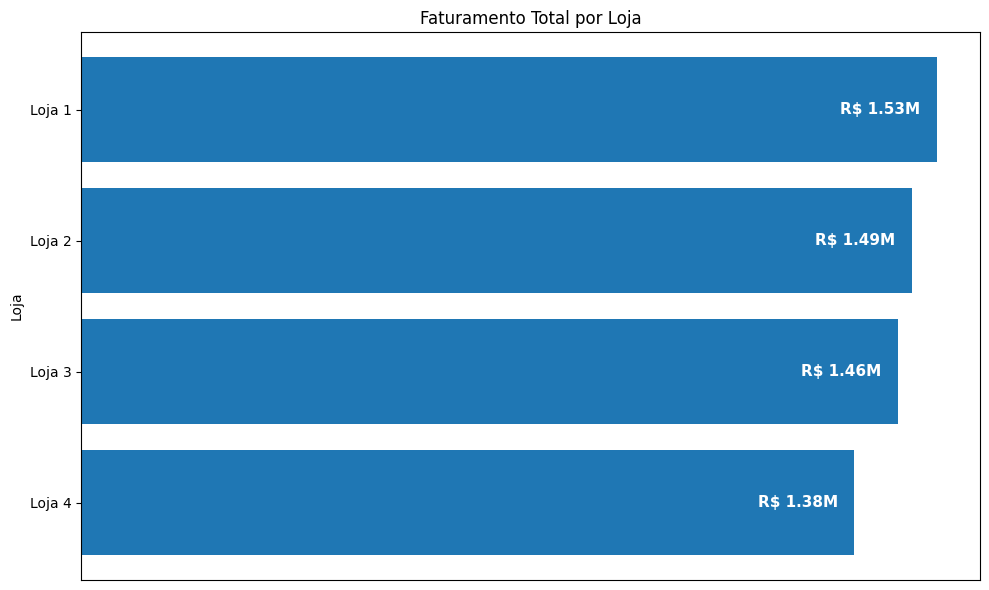

In [154]:
# GRÁFICO 1: Faturamento por Loja


faturamento = dados.groupby('Loja')['Preço'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
barras = plt.barh(faturamento.index, faturamento.values)

for i, barra in enumerate(barras):
    valor = faturamento.values[i]
    plt.text(valor - (valor * 0.02), i, f'R$ {valor/1000000:.2f}M',
             ha='right', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Faturamento Total por Loja')
plt.ylabel('Loja')
plt.xticks([])  # Remove o eixo X
plt.gca().invert_yaxis()  # Maior valor no topo
plt.tight_layout()
plt.show()


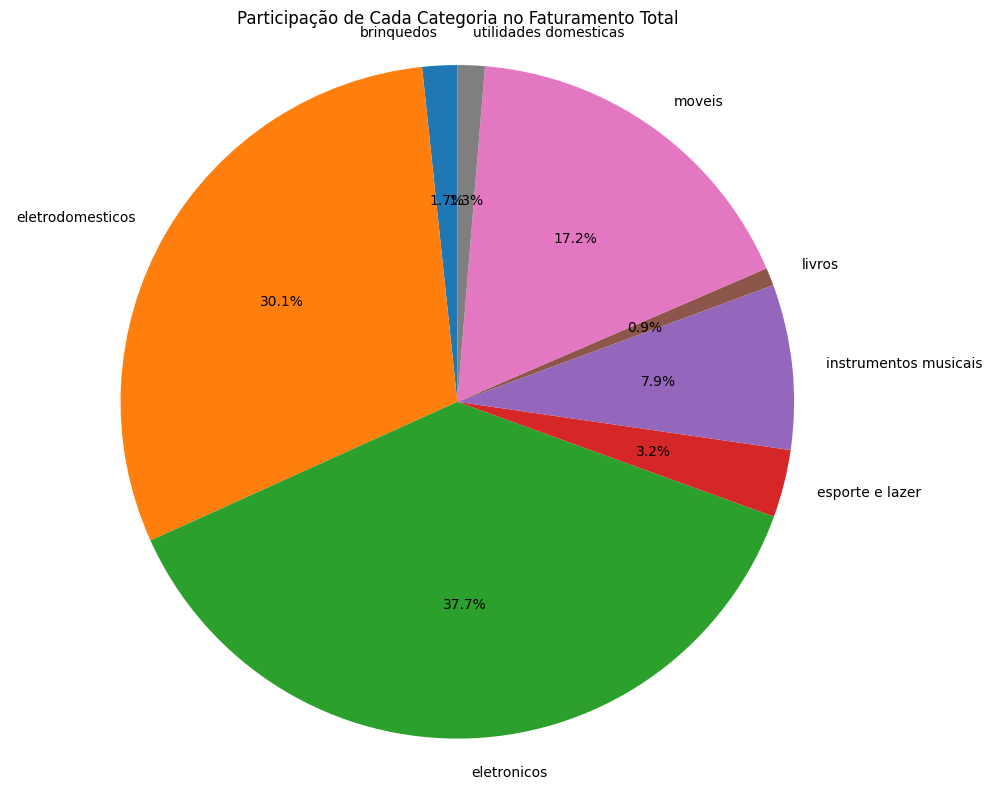

In [155]:
vendas_categoria = dados.groupby('Categoria do Produto')['Preço'].sum()

plt.figure(figsize=(10, 8))
plt.pie(vendas_categoria.values,
        labels=vendas_categoria.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title('Participação de Cada Categoria no Faturamento Total')
plt.axis('equal')  # Deixa o círculo redondo
plt.tight_layout()
plt.show()

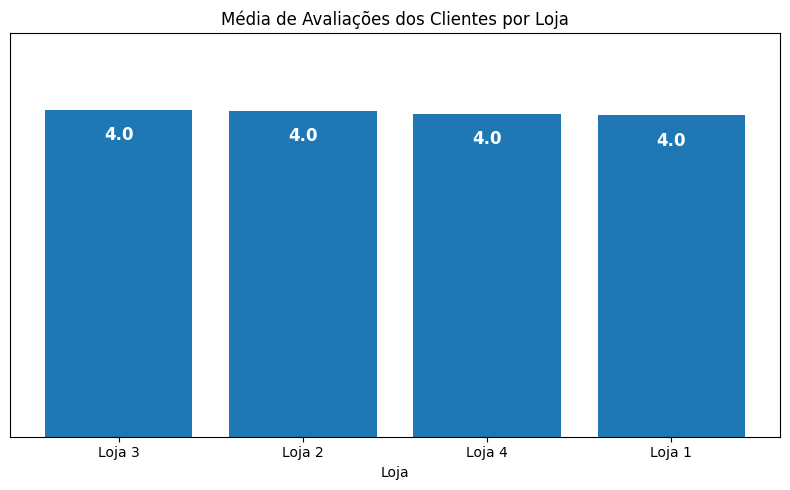

In [156]:
avaliacao = dados.groupby('Loja')['Avaliação da compra'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
barras = plt.bar(avaliacao.index, avaliacao.values)

# Adiciona os valores nas barras (extremidade interna superior)
for i, barra in enumerate(barras):
    altura = avaliacao.values[i]
    plt.text(barra.get_x() + barra.get_width()/2, altura - (altura * 0.05),
             f'{altura:.1f}',
             ha='center', va='top', fontsize=12, fontweight='bold', color='white')

plt.title('Média de Avaliações dos Clientes por Loja')
plt.xlabel('Loja')
plt.ylim(0, 5)
plt.yticks([])  # Remove o eixo Y
plt.tight_layout()
plt.show()

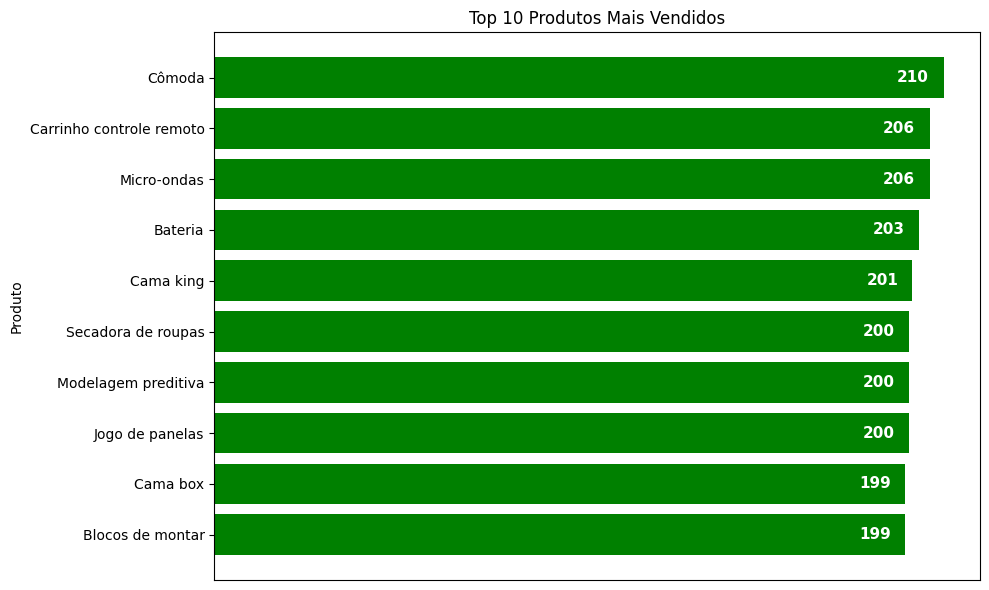

In [157]:
top_10 = contagem_vendas.head(10)

plt.figure(figsize=(10, 6))
barras = plt.barh(top_10.index, top_10.values, color='green')

# Adiciona os valores nas barras (extremidade interna direita)
for i, barra in enumerate(barras):
    valor = top_10.values[i]
    plt.text(valor - (valor * 0.02), i, f'{valor}',
             ha='right', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Top 10 Produtos Mais Vendidos')
plt.ylabel('Produto')
plt.xticks([])  # Remove o eixo X
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

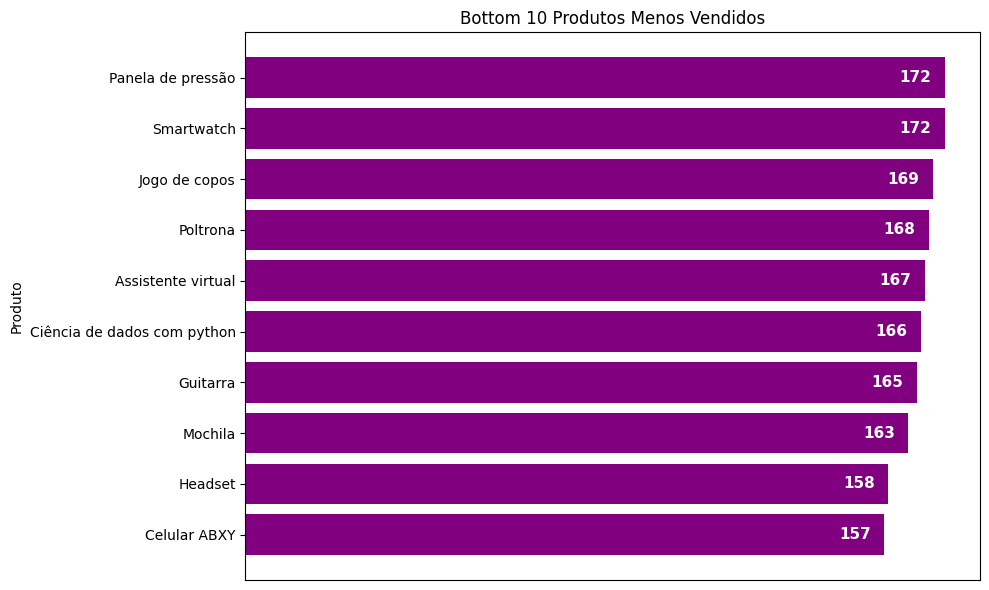

In [158]:
bottom_10 = contagem_vendas.tail(10).sort_values()

plt.figure(figsize=(10, 6))
barras = plt.barh(bottom_10.index, bottom_10.values, color='purple')

# Adiciona os valores nas barras (extremidade interna direita)
for i, barra in enumerate(barras):
    valor = bottom_10.values[i]
    plt.text(valor - (valor * 0.02), i, f'{valor}',
             ha='right', va='center', fontsize=11, fontweight='bold', color='white')

plt.title('Bottom 10 Produtos Menos Vendidos')
plt.ylabel('Produto')
plt.xticks([])  # Remove o eixo X
plt.tight_layout()
plt.show()

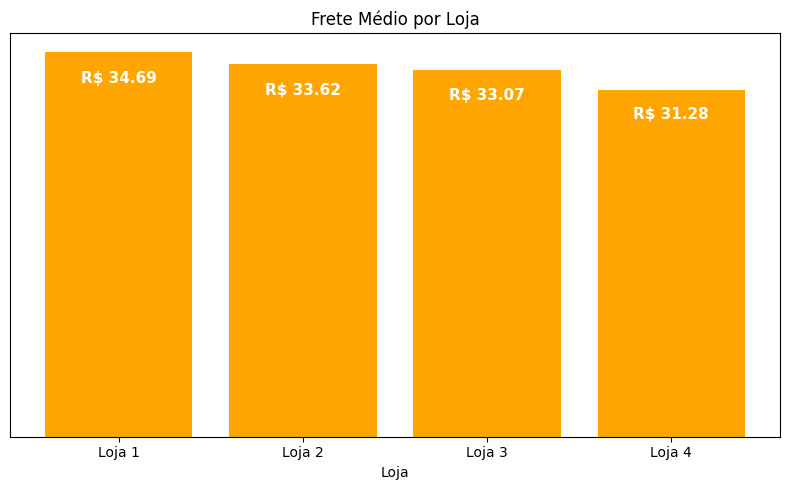

In [159]:
frete_medio = dados.groupby('Loja')['Frete'].mean()

plt.figure(figsize=(8, 5))
barras = plt.bar(frete_medio.index, frete_medio.values, color='orange')

# Adiciona os valores nas barras (extremidade interna superior)
for i, barra in enumerate(barras):
    altura = frete_medio.values[i]
    plt.text(barra.get_x() + barra.get_width()/2, altura - (altura * 0.05),
             f'R$ {altura:.2f}',
             ha='center', va='top', fontsize=11, fontweight='bold', color='white')

plt.title('Frete Médio por Loja')
plt.xlabel('Loja')
plt.yticks([])  # Remove o eixo Y
plt.tight_layout()
plt.show()